<a href="https://colab.research.google.com/github/Bhavana123448/PRODIGY_ML_01/blob/main/TASK01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/kc_house_data.csv", on_bad_lines='skip', engine='python')

print(df.head())
print(df.shape)

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [3]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [4]:
X = df[['sqft_living', 'bedrooms', 'bathrooms']]
y = df['price']

print(X.head())
print(y.head())

   sqft_living  bedrooms  bathrooms
0         1180         3       1.00
1         2570         3       2.25
2          770         2       1.00
3         1960         4       3.00
4         1680         3       2.00
0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (17290, 3)
Testing Data Shape: (4323, 3)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 502495.63808598  708281.0621956  1024918.29081449 1334049.20939344
  708403.56584406]


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 174662.93438524107
RMSE : 272465.84180991055
R2 Score : 0.5089347172264876


In [9]:
X = df[['sqft_living',
        'bedrooms',
        'bathrooms',
        'grade',
        'floors',
        'waterfront',
        'view',
        'condition',
        'yr_built']]

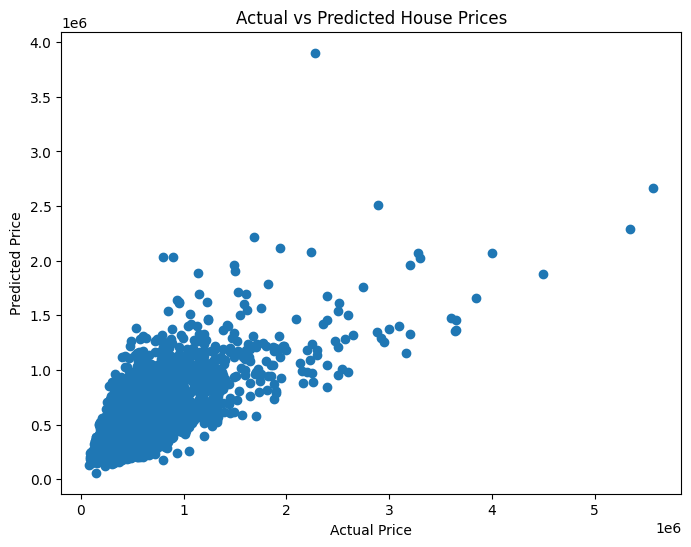

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [11]:
new_house = [[2500, 4, 3]]

predicted_price = model.predict(new_house)

print("Predicted House Price: $", predicted_price[0])

Predicted House Price: $ 642396.1646237117


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
X = df[['sqft_living', 'bedrooms', 'bathrooms']]
new_house = [[2500, 4, 3]]
new_house = pd.DataFrame({
    'sqft_living': [2500],
    'bedrooms': [4],
    'bathrooms': [3]
})

prediction = model.predict(new_house)

print(f"Predicted House Price: ${prediction[0]:,.2f}")

Predicted House Price: $642,396.16


In [13]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [14]:
import os

print(os.path.exists("house_price_model.pkl"))

True


In [15]:
import joblib

loaded_model = joblib.load("house_price_model.pkl")

new_house = pd.DataFrame({
    'sqft_living': [2500],
    'bedrooms': [4],
    'bathrooms': [3]
})

prediction = loaded_model.predict(new_house)

print(f"Predicted House Price: ${prediction[0]:,.2f}")

Predicted House Price: $642,396.16


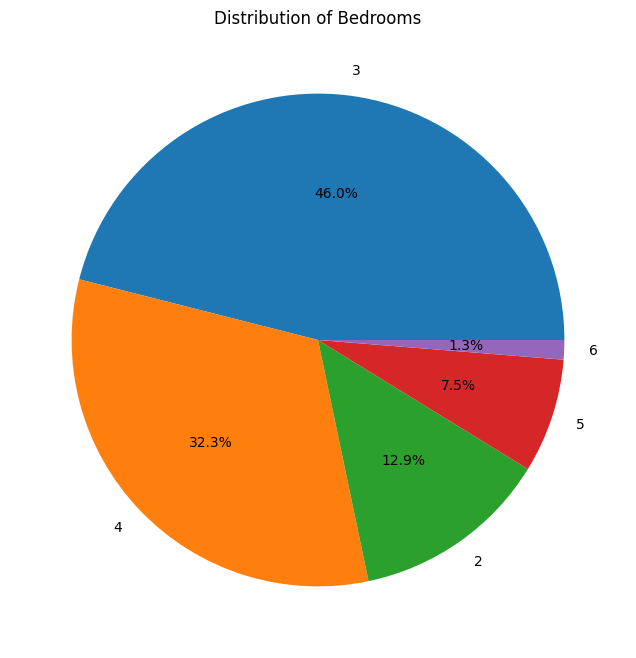

In [16]:
bedroom_counts = df['bedrooms'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    bedroom_counts,
    labels=bedroom_counts.index,
    autopct='%1.1f%%'
)
plt.title("Distribution of Bedrooms")
plt.show()

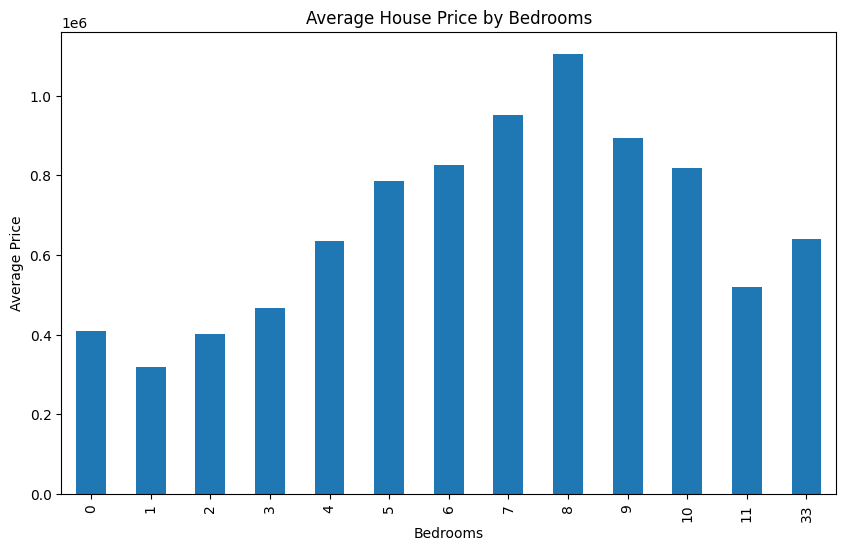

In [17]:
avg_price = df.groupby('bedrooms')['price'].mean()

plt.figure(figsize=(10,6))
avg_price.plot(kind='bar')

plt.title("Average House Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.show()

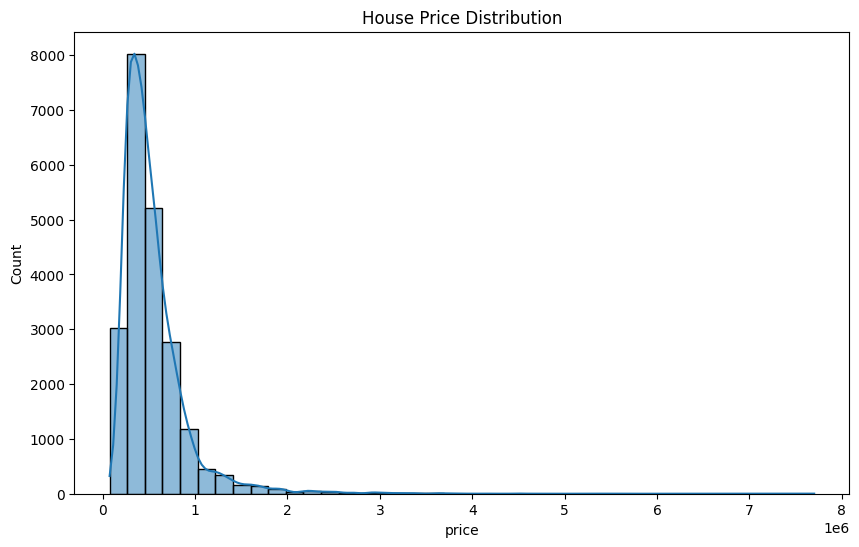

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=40, kde=True)

plt.title("House Price Distribution")
plt.show()

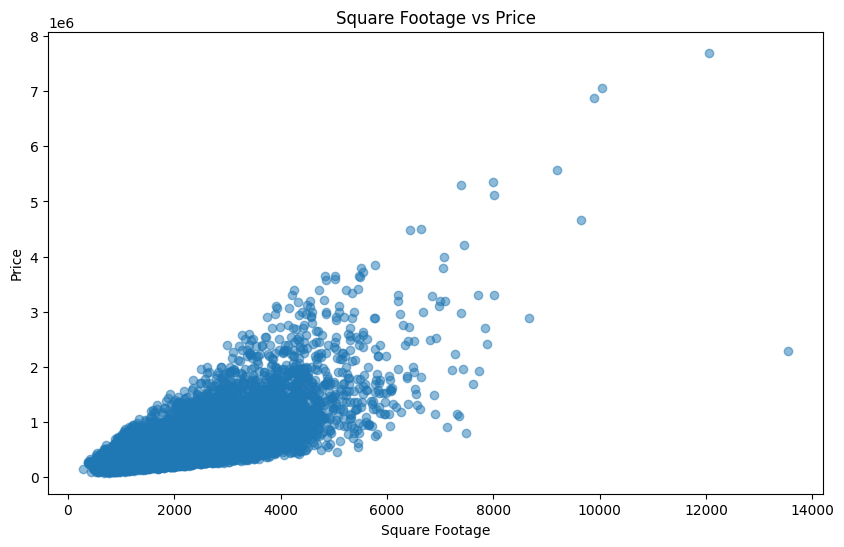

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(df['sqft_living'], df['price'], alpha=0.5)

plt.title("Square Footage vs Price")
plt.xlabel("Square Footage")
plt.ylabel("Price")
plt.show()

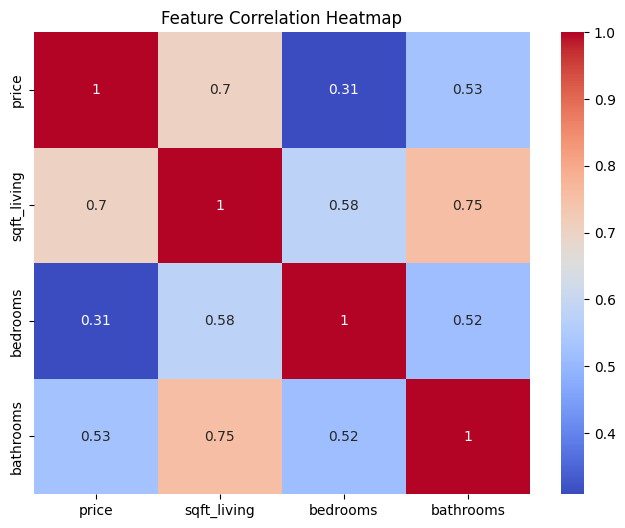

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['price','sqft_living','bedrooms','bathrooms']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

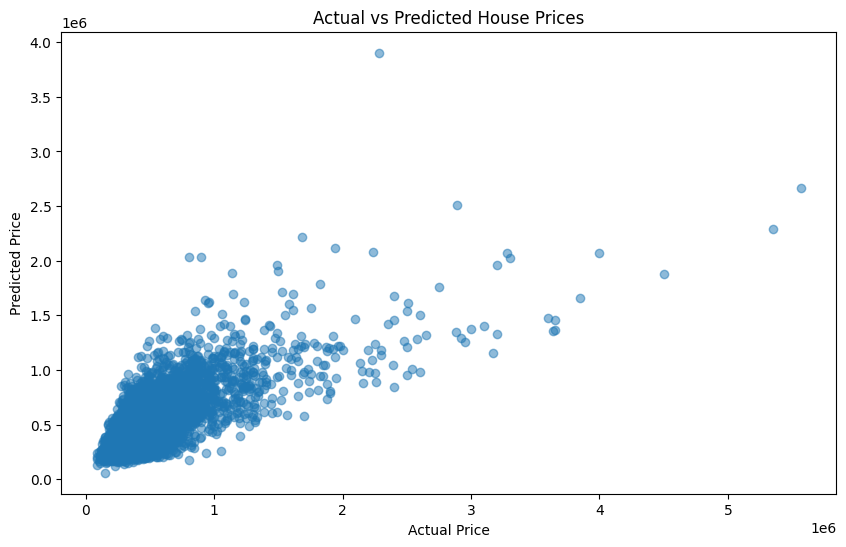

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()